In [3]:
import pandas as pd
df = pd.read_csv("dataset.csv")
#load the dataset


In [4]:
df.shape
# (rows, cols)

(7043, 21)

In [5]:
df.head()
# first five rows 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.tail()
# last five rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
missing = df.isnull().sum()
missing[missing>0]

Series([], dtype: int64)

In [11]:
df.duplicated().sum()

0

In [12]:
#if duplicates exist then run :
df = df.drop_duplicates()

In [13]:
df['Churn'].value_counts()
#here no means active costumers , and yes means the costumer who ended there subscriptions and closed there account


Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [14]:
df['Churn'].value_counts(normalize=True)*100
#percentage count

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

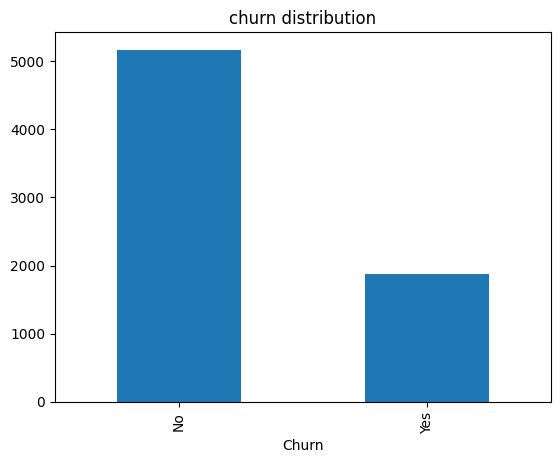

In [15]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')

plt.title("churn distribution")
plt.show()

In [16]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

print("Categorical Columns:")
print(cat_cols)

print()

print("Numerical Columns:")
print(num_cols)

Categorical Columns:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [17]:
df[df["TotalCharges"].str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [18]:
df[df["TotalCharges"].str.strip() == ""]["tenure"].value_counts()


tenure
0    11
Name: count, dtype: int64

In [19]:
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

In [20]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [22]:
df["TotalCharges"].isnull().sum()

11

In [23]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [24]:
df = df.dropna(subset=["TotalCharges"])

In [25]:
import numpy as np

df["TotalCharges"] = df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

df["TotalCharges"].isnull().sum()

0

In [26]:
df.shape

(7032, 21)

In [27]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [28]:
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

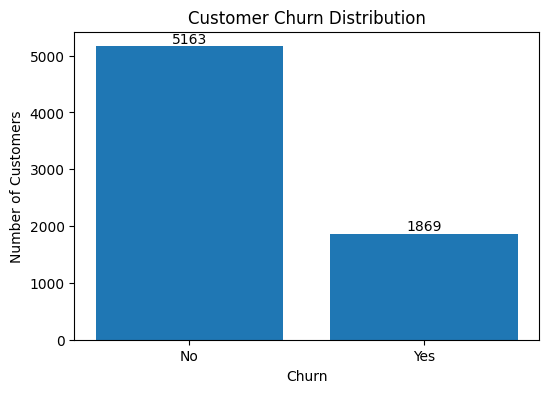

In [29]:
import matplotlib.pyplot as plt

counts = df["Churn"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(counts.index, counts.values)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(counts.values):
    plt.text(i, value + 50, str(value), ha="center")

plt.show()

In [30]:
(df["gender"].value_counts(normalize=True) * 100).round(2)

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

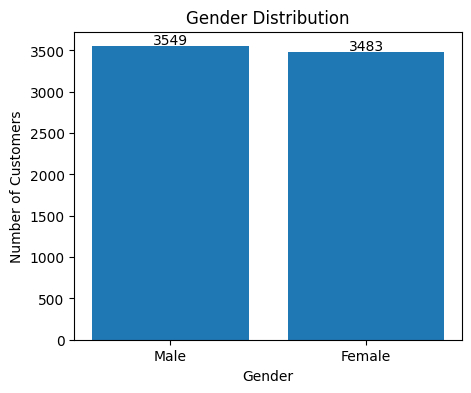

In [31]:
import matplotlib.pyplot as plt

gender_counts = df["gender"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for i, value in enumerate(gender_counts.values):
    plt.text(i, value + 20, str(value), ha="center")

plt.show()

In [32]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [33]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


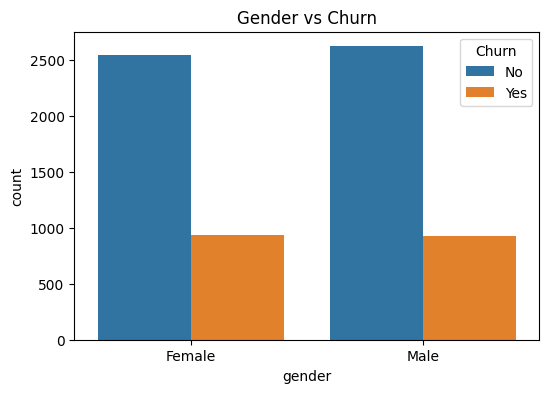

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Churn")
plt.show()

In [35]:
(df["Contract"].value_counts(normalize=True) * 100).round(2)

Contract
Month-to-month    55.11
Two year          23.96
One year          20.93
Name: proportion, dtype: float64

In [36]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [37]:
df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

(array([1051.,  309.,  364.,  235.,  216.,  284.,  167.,  170.,  224.,
         179.,  230.,  129.,  137.,  198.,  138.,  124.,  190.,  130.,
         112.,  206.,  134.,  218.,  132.,  145.,  203.,  146.,  152.,
         263.,  195.,  651.]),
 array([ 1.        ,  3.36666667,  5.73333333,  8.1       , 10.46666667,
        12.83333333, 15.2       , 17.56666667, 19.93333333, 22.3       ,
        24.66666667, 27.03333333, 29.4       , 31.76666667, 34.13333333,
        36.5       , 38.86666667, 41.23333333, 43.6       , 45.96666667,
        48.33333333, 50.7       , 53.06666667, 55.43333333, 57.8       ,
        60.16666667, 62.53333333, 64.9       , 67.26666667, 69.63333333,
        72.        ]),
 <BarContainer object of 30 artists>)

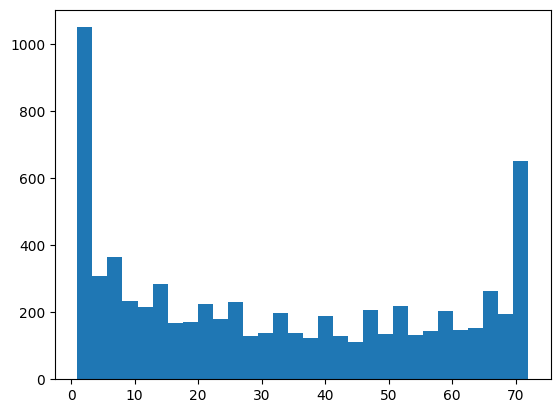

In [38]:
plt.hist(df["tenure"], bins=30)

<Axes: xlabel='tenure', ylabel='Count'>

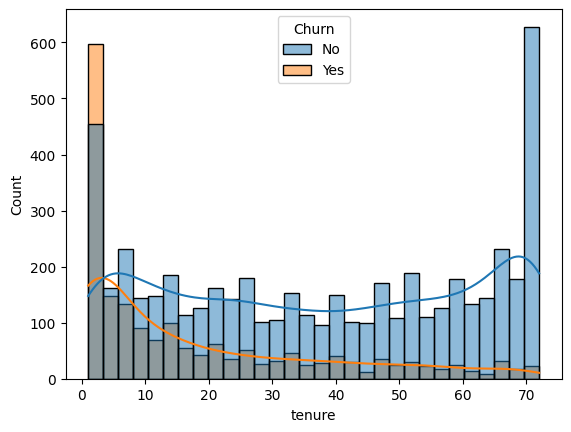

In [39]:
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

<Axes: xlabel='Churn', ylabel='tenure'>

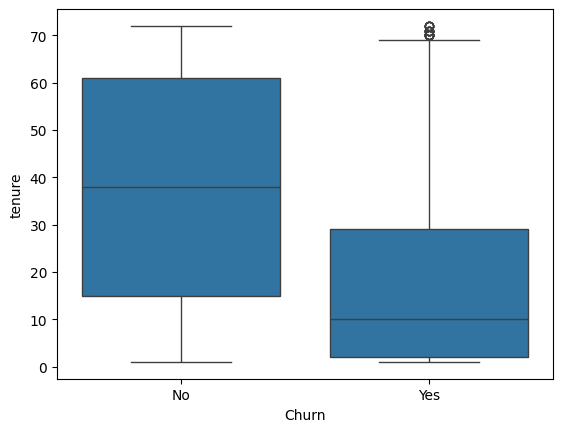

In [40]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

In [41]:
(df["InternetService"].value_counts(normalize=True) * 100).round(2)

InternetService
Fiber optic    44.03
DSL            34.36
No             21.62
Name: proportion, dtype: float64

In [42]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


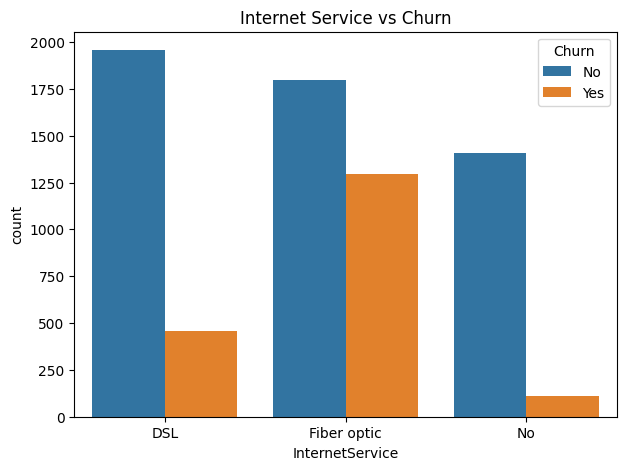

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")
plt.show()

In [44]:
df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

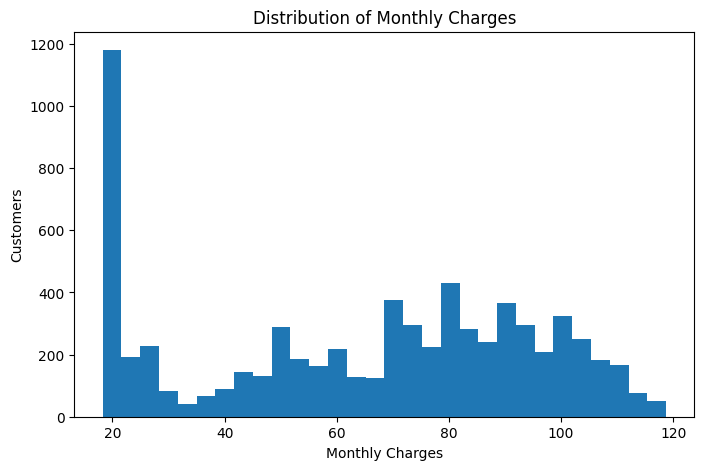

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["MonthlyCharges"], bins=30)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

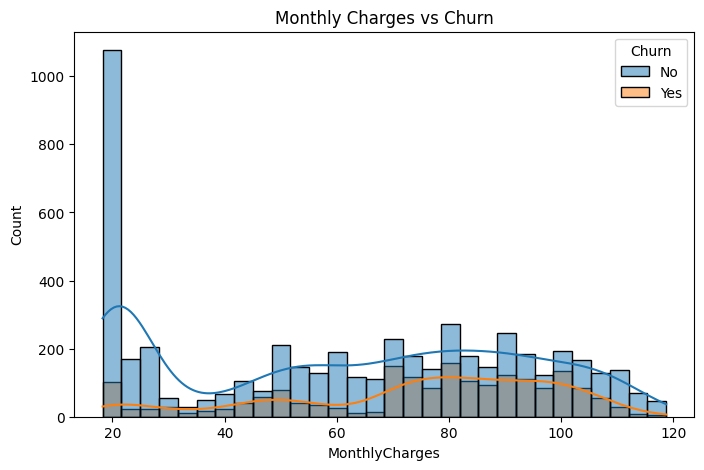

In [46]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Monthly Charges vs Churn")

plt.show()

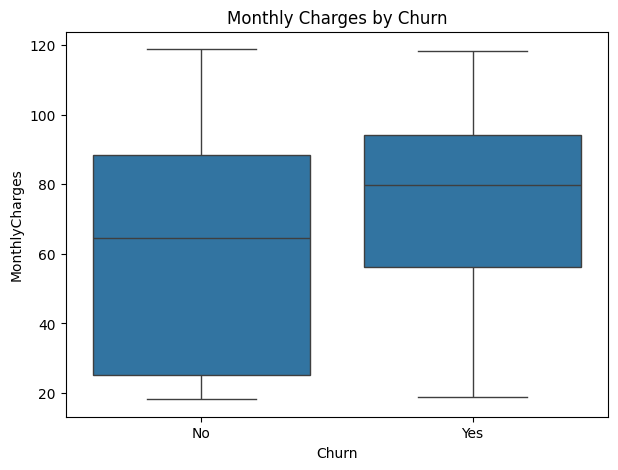

In [47]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")

plt.show()

In [48]:
df["TotalCharges"].describe()


count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

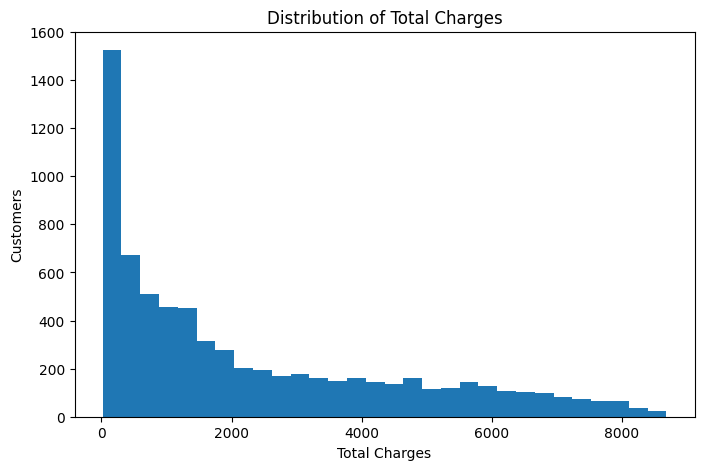

In [49]:
plt.figure(figsize=(8,5))

plt.hist(df["TotalCharges"], bins=30)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Customers")

plt.show()

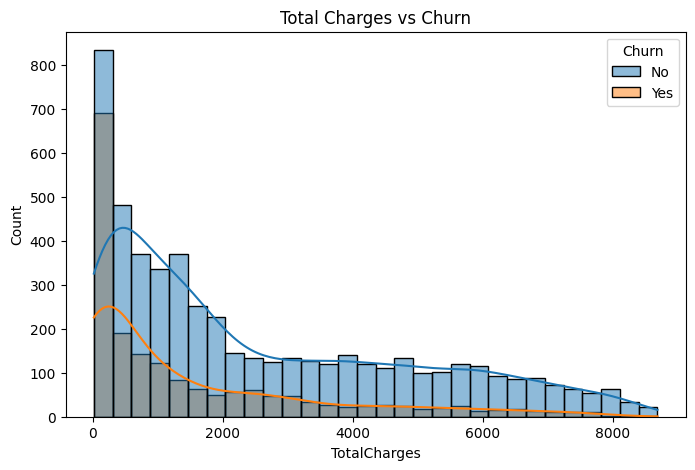

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="TotalCharges",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Total Charges vs Churn")

plt.show()

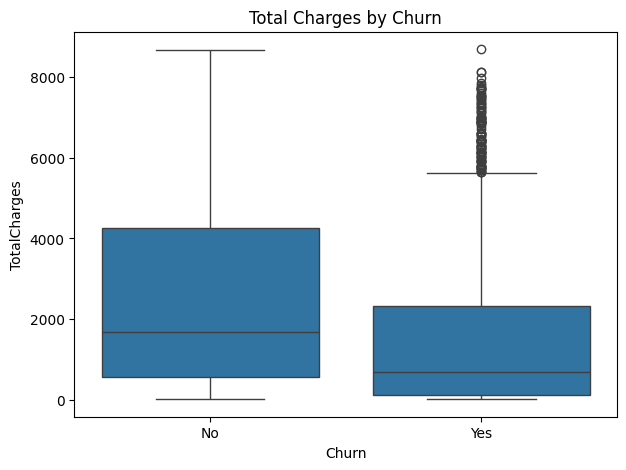

In [51]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")

plt.show()

In [52]:
num_df = df.select_dtypes(include=["int64", "float64"])

num_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [53]:
num_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


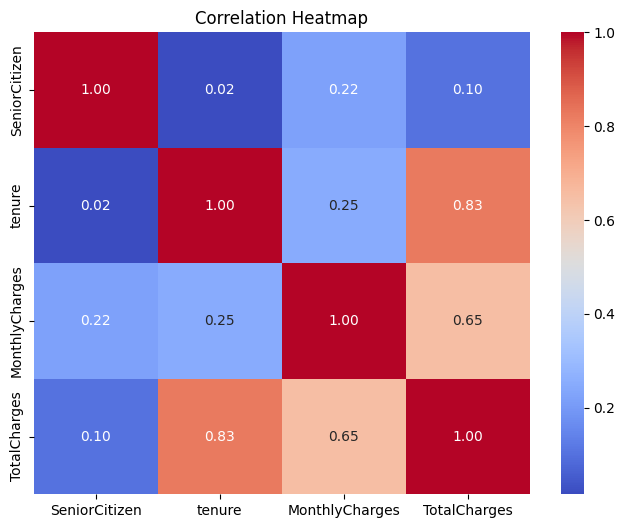

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    num_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [55]:
num_df = df.select_dtypes(include=["int64", "float64"])

num_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [56]:
df.drop("customerID", axis=1, inplace=True)

In [57]:
cat_cols = df.select_dtypes(include="object").columns

num_cols = df.select_dtypes(exclude="object").columns

print(cat_cols)
print(num_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [58]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")
    print("-" * 50)

gender: ['Female' 'Male']
--------------------------------------------------
Partner: ['Yes' 'No']
--------------------------------------------------
Dependents: ['No' 'Yes']
--------------------------------------------------
PhoneService: ['No' 'Yes']
--------------------------------------------------
MultipleLines: ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService: ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup: ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection: ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport: ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV: ['No' 'Yes' 'No internet service']
--------------------------------------------------

In [59]:
df_model = df.copy()

In [60]:
df_model["Churn"] = df_model["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [61]:
df_model["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [62]:
binary_cols = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling"
]

In [63]:
df_model["gender"] = df_model["gender"].map({
    "Female":0,
    "Male":1
})

In [64]:
for col in binary_cols[1:]:
    df_model[col] = df_model[col].map({
        "No":0,
        "Yes":1
    })

In [65]:
df_model[binary_cols].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling
0,0,1,0,0,1
1,1,0,0,1,0
2,1,0,0,1,1
3,1,0,0,0,0
4,0,0,0,1,1


In [66]:
df_model["Contract"] = df_model["Contract"].map({
    "Month-to-month":0,
    "One year":1,
    "Two year":2
})

In [67]:
df_model["Contract"].unique()

array([0, 1, 2], dtype=int64)

In [68]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,1,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,0,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,0,1,Electronic check,70.70,151.65,1


In [69]:
df_model.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,0,1,Electronic check,29.85,29.85,0
1,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,1,0,Mailed check,56.95,1889.50,0
2,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,0,1,Mailed check,53.85,108.15,1
3,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,1,0,Bank transfer (automatic),42.30,1840.75,0
4,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,0,1,Electronic check,70.70,151.65,1


In [70]:
nominal_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod"
]

In [71]:
df_model = pd.get_dummies(
    df_model,
    columns=nominal_cols,
    dtype=int
)

In [72]:
df_model.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,Contract,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,1,29.85,29.85,...,1,0,0,1,0,0,0,0,1,0
1,1,0,0,0,34,1,1,0,56.95,1889.50,...,1,0,0,1,0,0,0,0,0,1
2,1,0,0,0,2,1,0,1,53.85,108.15,...,1,0,0,1,0,0,0,0,0,1
3,1,0,0,0,45,0,1,0,42.30,1840.75,...,1,0,0,1,0,0,1,0,0,0
4,0,0,0,0,2,1,0,1,70.70,151.65,...,1,0,0,1,0,0,0,0,1,0


In [73]:
df_model.shape

(7032, 39)

In [74]:
X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [76]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 38)
(1407, 38)
(5625,)
(1407,)


In [77]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [78]:
scaler.fit(X_train)

StandardScaler()

In [79]:
X_train_scaled = scaler.transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [80]:
print(X_train_scaled[:5])

[[ 0.99627361 -0.43931886  1.02831173  1.5291432   1.3218163   0.32754155
   1.56711883 -1.21302973  0.98155578  1.6599004  -0.95905955 -0.32754155
   1.16554303 -0.72386272  1.12490211 -0.52296156 -0.99662791 -0.52296156
   1.57642955 -0.87716837 -0.52296156  1.36157309 -0.88576589 -0.52296156
   1.37605179 -0.98115531 -0.52296156  1.54681665  1.23432296 -0.52296156
  -0.79787323  1.23753915 -0.52296156 -0.79996356 -0.5303972   1.90515869
  -0.71617747 -0.5394682 ]
 [ 0.99627361 -0.43931886 -0.97246775 -0.65396099 -0.26741023 -3.05304781
  -0.83087992 -1.21302973 -0.97154551 -0.56225219 -0.95905955  3.05304781
  -0.85796918  1.38147741 -0.88896624 -0.52296156  1.0033835  -0.52296156
  -0.63434487  1.14003199 -0.52296156 -0.7344446  -0.88576589 -0.52296156
   1.37605179 -0.98115531 -0.52296156  1.54681665  1.23432296 -0.52296156
  -0.79787323  1.23753915 -0.52296156 -0.79996356 -0.5303972  -0.52489066
   1.39630196 -0.5394682 ]
 [-1.00374033 -0.43931886  1.02831173 -0.65396099  1.44406

In [81]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [82]:
print(lr_model.coef_)

[[-0.01168349  0.07073816 -0.0131312  -0.10570211 -1.3465605   0.0231551
  -0.60625993  0.14299855 -0.90145689  0.63894614 -0.10218328 -0.0231551
   0.11715419 -0.3271916   0.40731157 -0.11406963  0.1178739  -0.11406963
  -0.02673626  0.06212539 -0.11406963  0.03363096  0.0132583  -0.11406963
   0.08466234  0.10787856 -0.11406963 -0.01554292 -0.08024226 -0.11406963
   0.17659066 -0.07388961 -0.11406963  0.17007859 -0.06075479 -0.04255766
   0.11363829 -0.02663939]]


In [83]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
9,TotalCharges,0.638946
14,InternetService_Fiber optic,0.407312
30,StreamingTV_Yes,0.176591
33,StreamingMovies_Yes,0.170079
7,PaperlessBilling,0.142999
16,OnlineSecurity_No,0.117874
12,MultipleLines_Yes,0.117154
36,PaymentMethod_Electronic check,0.113638
25,TechSupport_No,0.107879
24,DeviceProtection_Yes,0.084662


In [84]:
y_pred = lr_model.predict(
    X_test_scaled
)

y_prob = lr_model.predict_proba(
    X_test_scaled
)

In [85]:
print(y_pred)
print(y_prob)

[0 1 0 ... 0 0 0]
[[0.9837265  0.0162735 ]
 [0.4044413  0.5955587 ]
 [0.99544762 0.00455238]
 ...
 [0.86511258 0.13488742]
 [0.97632223 0.02367777]
 [0.9958084  0.0041916 ]]


In [86]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


In [87]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[916 117]
 [159 215]]


In [88]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [89]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(
    y_test,
    y_prob[:,1]
)

print("ROC-AUC:", roc)

ROC-AUC: 0.8356986814791041


In [90]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, dt_pred)

print("Accuracy: ", accuracy)

cm = confusion_matrix(y_test, dt_pred)

print("confusion matrix: ", cm)

cr = classification_report(y_test, dt_pred)

print("classification report: ", cr)

roc = roc_auc_score(y_test, dt_prob[:,1])

print("ROC-AUC: ", roc)


Accuracy:  0.7256574271499645
confusion matrix:  [[832 201]
 [185 189]]
classification report:                precision    recall  f1-score   support

           0       0.82      0.81      0.81      1033
           1       0.48      0.51      0.49       374

    accuracy                           0.73      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.73      0.73      1407

ROC-AUC:  0.6556289505153465


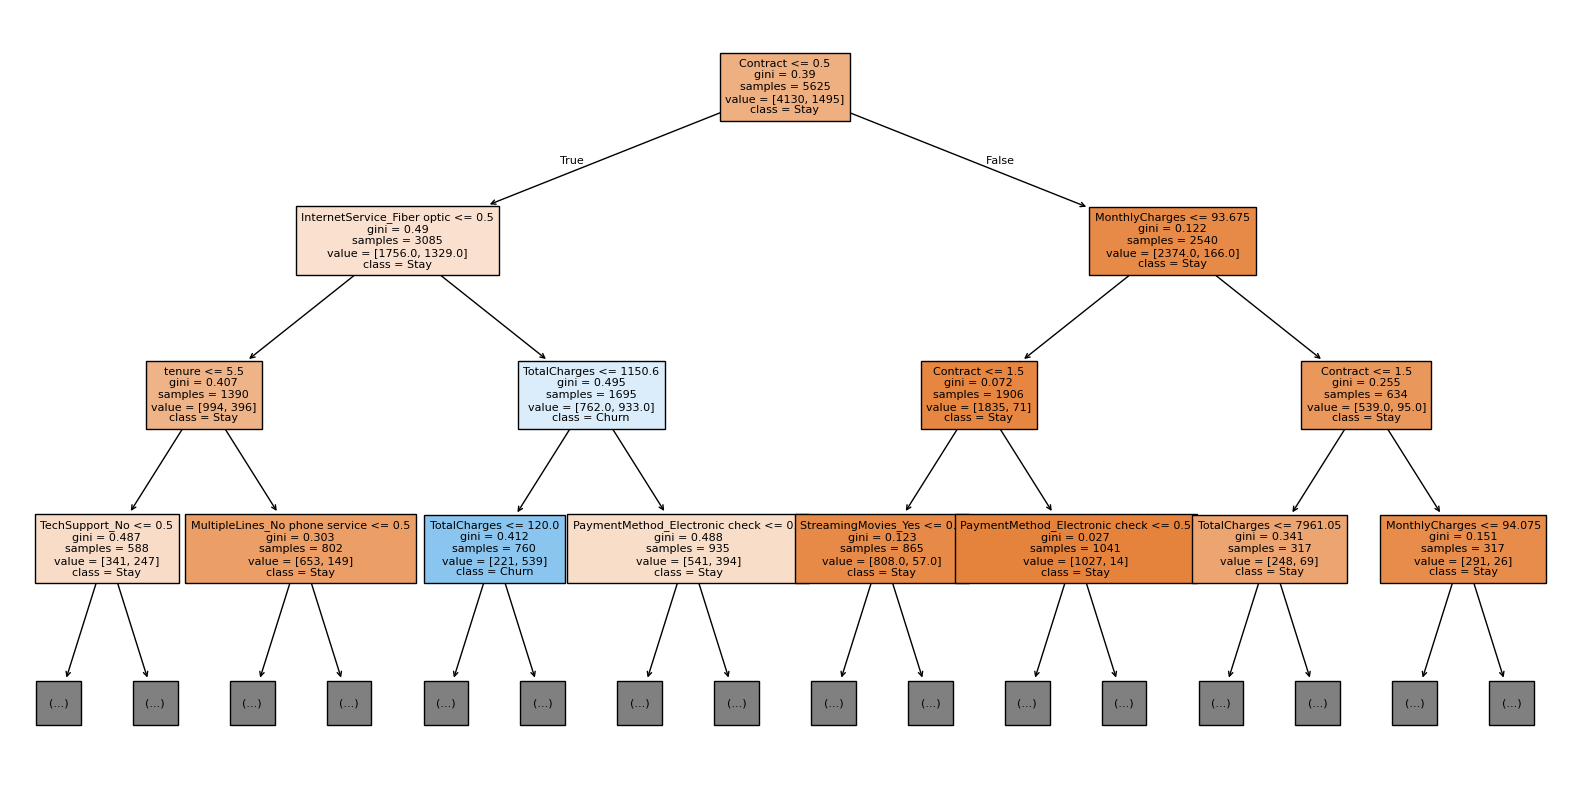

In [91]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Stay","Churn"],
    filled=True,
    max_depth=3,
    fontsize=8
)

plt.show()

In [94]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, rf_pred)
print("accuracy=", accuracy)

print("confusion_matrix: ", confusion_matrix(y_test, rf_pred))

print("classification report: ", classification_report(y_test, rf_pred))

roc_score = roc_auc_score(y_test, rf_prob[:,1])
print("roc_auc_Score: ",roc_score)

accuracy= 0.7903340440653873
confusion_matrix:  [[926 107]
 [188 186]]
classification report:                precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

roc_auc_Score:  0.8107518726931061


In [95]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                                    Feature  Importance
9                              TotalCharges    0.174396
8                            MonthlyCharges    0.148610
4                                    tenure    0.145378
6                                  Contract    0.076159
16                        OnlineSecurity_No    0.035829
36           PaymentMethod_Electronic check    0.029656
0                                    gender    0.028181
25                           TechSupport_No    0.028014
7                          PaperlessBilling    0.025441
2                                   Partner    0.023103
14              InternetService_Fiber optic    0.022644
1                             SeniorCitizen    0.020081
3                                Dependents    0.019485
19                          OnlineBackup_No    0.015953
22                      DeviceProtection_No    0.014767
12                        MultipleLines_Yes    0.014071
10                         MultipleLines_No    0

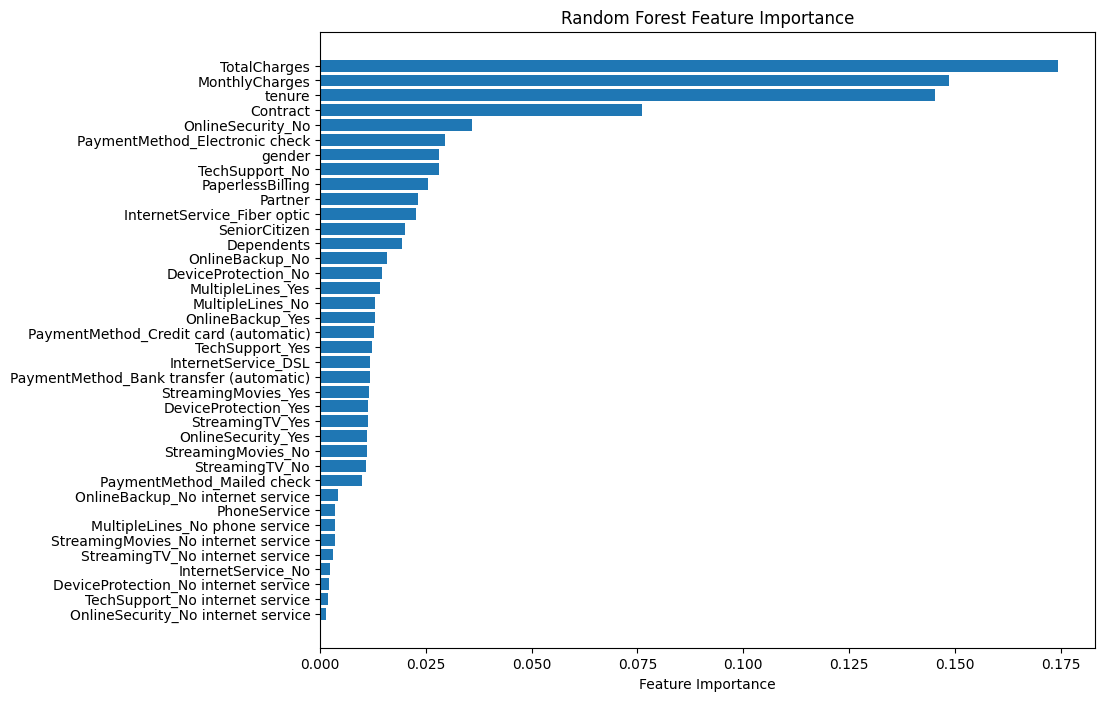

In [96]:
import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")

plt.show()

In [97]:
pip install xgboost

     ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
     --------------------------------------- 0.7/101.7 MB 15.0 MB/s eta 0:00:07
      -------------------------------------- 2.1/101.7 MB 26.5 MB/s eta 0:00:04
     - ------------------------------------- 4.0/101.7 MB 28.2 MB/s eta 0:00:04
     -- ------------------------------------ 6.2/101.7 MB 33.1 MB/s eta 0:00:03
     --- ----------------------------------- 8.3/101.7 MB 35.6 MB/s eta 0:00:03
     ---- --------------------------------- 10.9/101.7 MB 43.7 MB/s eta 0:00:03
     ---- --------------------------------- 13.1/101.7 MB 54.7 MB/s eta 0:00:02
     ----- -------------------------------- 15.6/101.7 MB 50.4 MB/s eta 0:00:02
     ------ ------------------------------- 17.5/101.7 MB 50.1 MB/s eta 0:00:02
     ------- ------------------------------ 19.6/101.7 MB 46.9 MB/s eta 0:00:02
     -------- ----------------------------- 22.0/101.7 MB 46.9 MB/s eta 0:00:02
     -------- ----------------------------- 24.


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [98]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = "logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

accuracy = accuracy_score(y_test, xgb_pred)
print("Accuracy:", accuracy)

print(confusion_matrix(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

roc = roc_auc_score(y_test, xgb_prob[:,1])
print("ROC-AUC:", roc)

Accuracy: 0.7697228144989339
[[882 151]
 [173 201]]
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.54      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

ROC-AUC: 0.8116435696869613


In [99]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [100]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [101]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [102]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
0.8042666666666667


In [103]:
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_test)
best_prob = best_rf.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, best_pred))
print(confusion_matrix(y_test, best_pred))
print(classification_report(y_test, best_pred))
print("ROC-AUC:", roc_auc_score(y_test, best_prob[:, 1]))

Accuracy: 0.7860696517412935
[[916 117]
 [184 190]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8307018134191985


In [107]:
pip install shap

     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     --- ------------------------------------ 51.2/547.0 kB ? eta -:--:--
     ---- -------------------------------- 61.4/547.0 kB 656.4 kB/s eta 0:00:01
     ---- -------------------------------- 61.4/547.0 kB 656.4 kB/s eta 0:00:01
     ---- -------------------------------- 61.4/547.0 kB 656.4 kB/s eta 0:00:01
     -------- --------------------------- 122.9/547.0 kB 554.9 kB/s eta 0:00:01
     -------- --------------------------- 122.9/547.0 kB 554.9 kB/s eta 0:00:01
     ------------ ----------------------- 194.6/547.0 kB 620.6 kB/s eta 0:00:01
     ------------ ----------------------- 194.6/547.0 kB 620.6 kB/s eta 0:00:01
     ------------ ----------------------- 194.6/547.0 kB 620.6 kB/s eta 0:00:01
     -------------------- --------------- 307.2/547.0 kB 731.4 kB/s


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [108]:
import shap

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

c:\Users\athar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


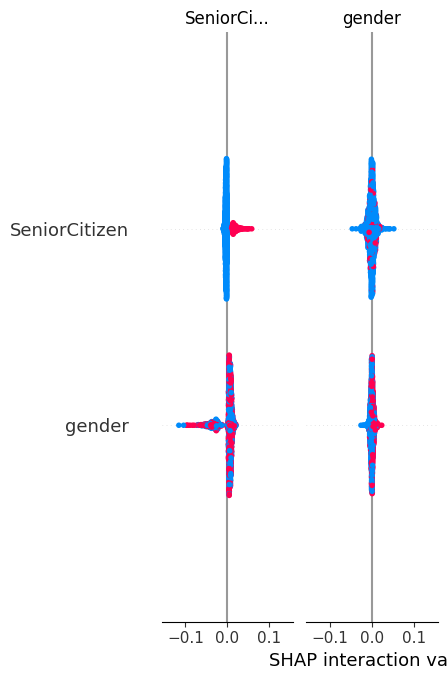

In [109]:
shap.summary_plot(shap_values, X_test)

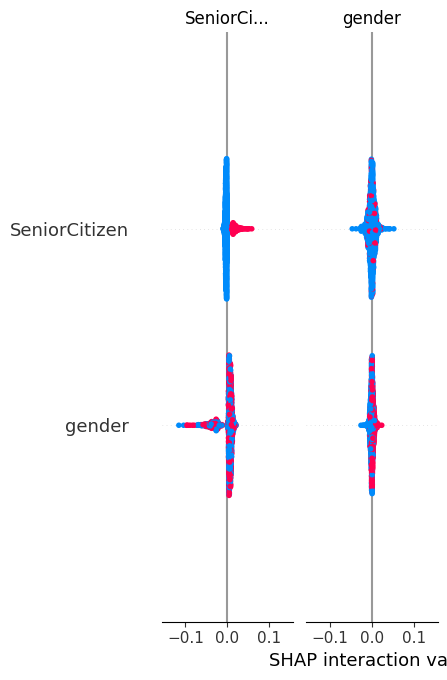

In [110]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

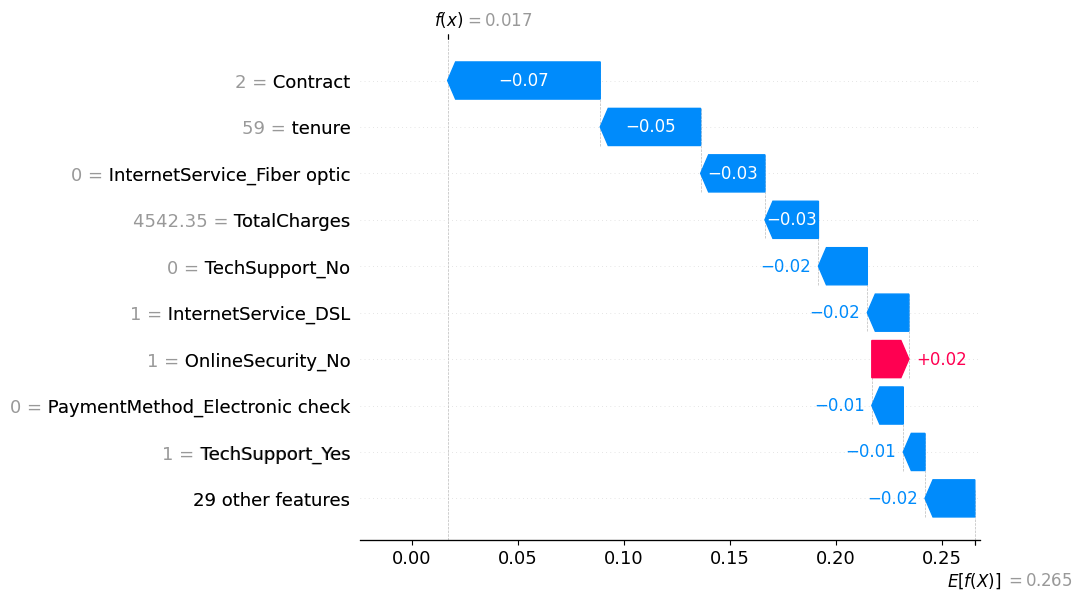

In [118]:
sample = 0

explanation = shap.Explanation(
    values=shap_values[sample, :, 1],
    base_values=explainer.expected_value[1],
    data=X_test.iloc[sample],
    feature_names=X_test.columns
)

shap.plots.waterfall(explanation)

In [119]:
import joblib
joblib.dump(best_rf, "churn_model.pkl")
loaded_model = joblib.load("churn_model.pkl")
prediction = loaded_model.predict(X_test)

print(prediction[:10])

[0 1 0 0 0 0 0 0 1 0]
